# BANA273 Final Project: Predicting Academic Performance from Social Media Addiction Patterns
Machine Learning Analytics | Professor Mingdi Xin | MSBA Fall 2026

Team 10A: Claudia Garcia, Nathacia N, Ernesto Mata, Qitong Ou, Tony Liang 
 
____
### Objective
This project aims to predict students’ academic performance based on their social media usage and addiction patterns. By analyzing behavioral and demographic factors such as daily usage time, addiction score, mental health, and sleep habits, the study seeks to identify early indicators of academic risk and provide insights into how digital behavior influences learning outcomes.

### About the Data
The near-perfect separability and extremely strong predictor–target relationships suggest that 
the dataset is highly structured and cleaner than what is typically observed in real-world 
behavioral surveys. While not explicitly synthetic, the data behaves in a way that allows 
models to achieve perfect accuracy, which should be interpreted with caution.


### Research Question
*Do social media usage and addiction patterns affect students’ academic performance?*
____

### I. Setup & Data Loading

In [70]:
# importing packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
# setting themes
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid", palette="pastel")

# loading dataset
df = pd.read_csv("Students Social Media Addiction.csv")
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


### II. Data Preprocessing & Cleaning

In [3]:
# examine data structure
print("Dataset shape:", df.shape)

# examine data types
print("\nData types:")
print(df.dtypes)

# checking for missing values
print("\nMissing values per column:")
print(df.isna().sum())

Dataset shape: (705, 13)

Data types:
Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

Missing values per column:
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Medi

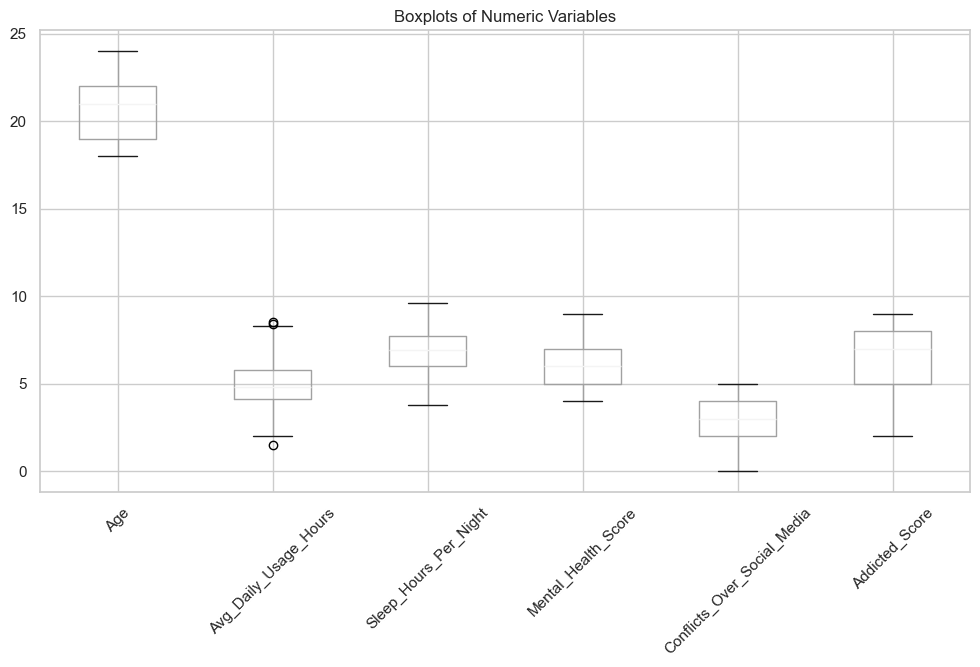

In [6]:
# visualize outliers for numeric columns
numeric_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Conflicts_Over_Social_Media",
    "Addicted_Score"
]

df[numeric_cols].boxplot(figsize=(12,6))
plt.title("Boxplots of Numeric Variables")
plt.xticks(rotation=45)
plt.show()

In [9]:
# inspect numeric columns
df[numeric_cols].describe()

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


The numeric variables fall within realistic and expected ranges for a student survey dataset:
- **Age (18–24):** Reasonable for high school, undergraduate, and graduate students.  
- **Avg_Daily_Usage_Hours (1.5–8.5 hours):** Values represent typical to heavy social media usage; no impossible values (e.g., > 24 hours).  
- **Sleep_Hours_Per_Night (3.8–9.6 hours):** All values fall within a plausible biological range.  
- **Mental_Health_Score (4–9):** Reports fall within the expected 1–10–style rating scale.  
- **Conflicts_Over_Social_Media (0–5):** No extreme or invalid values.  
- **Addicted_Score (2–9):** Scores fit the standardized 1–10 scale used in the survey.

Although some variables show higher values (e.g., usage hours or conflict frequency), these represent legitimate heavy social media users, not data errors. Therefore, **no outlier removal is needed**.

In [7]:
# check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [4]:
# encoding target variable
df["Affects_Academic_Performance_binary"] = df["Affects_Academic_Performance"].map({"Yes": 1, "No": 0})

df["Affects_Academic_Performance_binary"].value_counts()


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Affects_Academic_Performance_binary
1    453
0    252
Name: count, dtype: int64

In [ ]:
# class balance check
counts = df["Affects_Academic_Performance_binary"].value_counts()
perc = counts / len(df) * 100

print("Counts:\n", counts)
print("\nPercentages:\n", perc)

sns.barplot(x=counts.index, y=counts.values)
plt.xticks([0,1], ["No (0)", "Yes (1)"])
plt.title("Target Class Distribution")
plt.ylabel("Count")
plt.show()

The target variable is moderately imbalanced.  
Because of this, we will use **stratified cross-validation** and evaluate models using **Precision, Recall, F1, and Lift**, in addition to Accuracy.

In [34]:
# inspect categorical variables
categorical_cols = [
    "Gender",
    "Academic_Level",
    "Most_Used_Platform",
    "Relationship_Status",
    "Country"
]

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    
# inspect all 110 unique country entries
#sorted(df["Country"].unique())

Gender: 2 unique values
Academic_Level: 3 unique values
Most_Used_Platform: 12 unique values
Relationship_Status: 3 unique values
Country: 110 unique values


In [26]:
# region mapping
asia = [
    "Afghanistan","Armenia","Azerbaijan","Bahrain","Bangladesh","Bhutan",
    "China","Georgia","Hong Kong","India","Indonesia","Iraq","Israel",
    "Japan","Jordan","Kazakhstan","Kuwait","Kyrgyzstan","Lebanon",
    "Malaysia","Maldives","Nepal","Oman","Pakistan","Philippines","Qatar",
    "Russia","Singapore","South Korea","Sri Lanka","Syria","Taiwan",
    "Tajikistan","Thailand","Turkey","UAE","Uzbekistan","Vietnam","Yemen"
]

europe = [
    "Albania","Andorra","Austria","Belarus","Belgium","Bosnia","Bulgaria",
    "Croatia","Cyprus","Czech Republic","Denmark","Estonia","Finland",
    "France","Germany","Greece","Hungary","Iceland","Ireland","Italy",
    "Kosovo","Latvia","Liechtenstein","Lithuania","Luxembourg","Malta",
    "Moldova","Monaco","Montenegro","Netherlands","North Macedonia","Norway",
    "Poland","Portugal","Romania","San Marino","Serbia","Slovakia","Slovenia",
    "Spain","Sweden","Switzerland","Ukraine","UK","Vatican City"
]

north_america = [
    "Bahamas","Canada","Costa Rica","Jamaica","Mexico","Panama","Trinidad","USA"
]

south_america = [
    "Argentina","Bolivia","Brazil","Chile","Colombia","Ecuador","Paraguay",
    "Peru","Uruguay","Venezuela"
]

africa = ["Egypt","Ghana","Kenya","Morocco","Nigeria","South Africa"]

oceania = ["Australia","New Zealand"]

# create new country_region variable
def map_region(country):
    if country in asia: return "Asia"
    elif country in europe: return "Europe"
    elif country in north_america: return "North America"
    elif country in south_america: return "South America"
    elif country in africa: return "Africa"
    elif country in oceania: return "Oceania"
    else: return "Other"

df["Country_Region"] = df["Country"].apply(map_region)

df["Country_Region"].value_counts()

Country_Region
Asia             296
Europe           258
North America    106
Oceania           22
South America     17
Africa             6
Name: count, dtype: int64

In [35]:
# inspect most_used_platform
df["Most_Used_Platform"].value_counts()

Most_Used_Platform
Instagram    249
TikTok       154
Facebook     123
WhatsApp      54
Twitter       30
LinkedIn      21
WeChat        15
Snapchat      13
VKontakte     12
LINE          12
KakaoTalk     12
YouTube       10
Name: count, dtype: int64

In [36]:
# numerical columns have been defined
# defining categorical columns
categorical_cols = [
    "Gender",
    "Academic_Level",
    "Most_Used_Platform",
    "Relationship_Status",
    "Country_Region"
]
target = "Affects_Academic_Performance_binary"

X = df[numeric_cols + categorical_cols]
y = df[target]

# encode categorical predictors
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_encoded.head()
#X_encoded.columns

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Gender_Male,Academic_Level_High School,Academic_Level_Undergraduate,Most_Used_Platform_Instagram,...,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Relationship_Status_In Relationship,Relationship_Status_Single,Country_Region_Asia,Country_Region_Europe,Country_Region_North America,Country_Region_Oceania,Country_Region_South America
0,19,5.2,6.5,6,3,8,False,False,True,True,...,False,False,False,True,False,True,False,False,False,False
1,22,2.1,7.5,8,0,3,True,False,False,False,...,False,False,False,False,True,True,False,False,False,False
2,20,6.0,5.0,5,4,9,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,18,3.0,7.0,7,1,4,True,True,False,False,...,False,False,True,False,True,False,True,False,False,False
4,21,4.5,6.0,6,2,7,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False


In [63]:
# standardize numeric variables
scaler = StandardScaler()

X_scaled = X_encoded.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_scaled[numeric_cols])

X_scaled.head()

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Gender_Male,Academic_Level_High School,Academic_Level_Undergraduate,Most_Used_Platform_Instagram,...,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Relationship_Status_In Relationship,Relationship_Status_Single,Country_Region_Asia,Country_Region_Europe,Country_Region_North America,Country_Region_Oceania,Country_Region_South America
0,-1.186915,0.223857,-0.327638,-0.205520,0.157063,0.985550,False,False,True,True,...,False,False,False,True,False,True,False,False,False,False
1,0.958662,-2.243309,0.560423,1.605628,-2.976790,-2.166958,True,False,False,False,...,False,False,False,False,True,True,False,False,False,False
2,-0.471723,0.860545,-1.659730,-1.111095,1.201681,1.616052,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,-1.902108,-1.527035,0.116393,0.700054,-1.932172,-1.536456,True,True,False,False,...,False,False,True,False,True,False,True,False,False,False
4,0.243470,-0.333245,-0.771668,-0.205520,-0.887554,0.355048,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False


In [66]:
# standardize sanity check
X_scaled[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,705.0,-9.070758e-16,1.00071,-1.902108,-1.186915,0.243470,0.958662,2.389048
Avg_Daily_Usage_Hours,705.0,1.612579e-16,1.00071,-2.720825,-0.651589,-0.094487,0.701373,2.850195
Sleep_Hours_Per_Night,705.0,-2.922800e-16,1.00071,-2.725403,-0.771668,0.027587,0.738036,2.425352
Mental_Health_Score,705.0,-3.073979e-16,1.00071,-2.016669,-1.111095,-0.205520,0.700054,2.511203
Conflicts_Over_Social_Media,705.0,0.000000e+00,1.00071,-2.976790,-0.887554,0.157063,1.201681,2.246298
Addicted_Score,705.0,-1.209434e-16,1.00071,-2.797459,-0.905955,0.355048,0.985550,1.616052


### III. Exploratory Data Analysis

In [39]:
# summary of numeric columns
df[numeric_cols].describe()

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


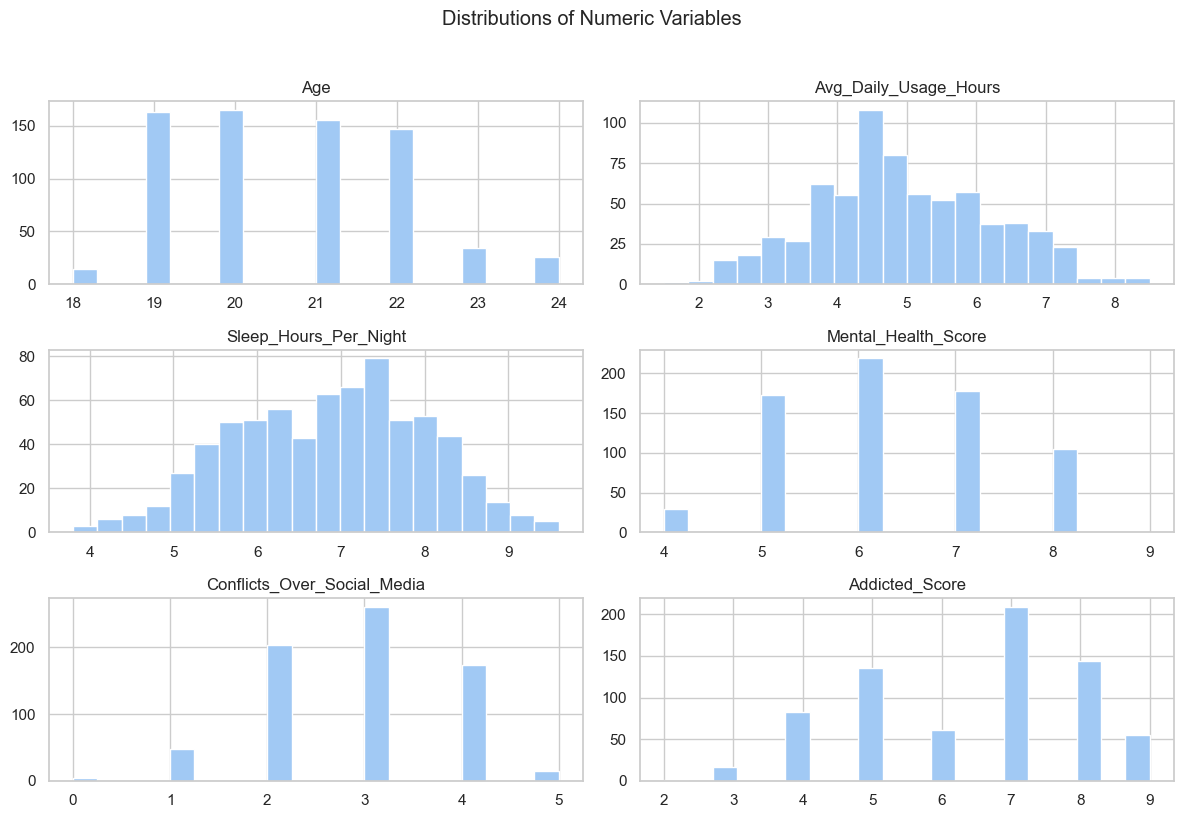

In [41]:
# plot distributions of numeric variables
df[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distributions of Numeric Variables", y=1.02)
plt.tight_layout()
plt.show()

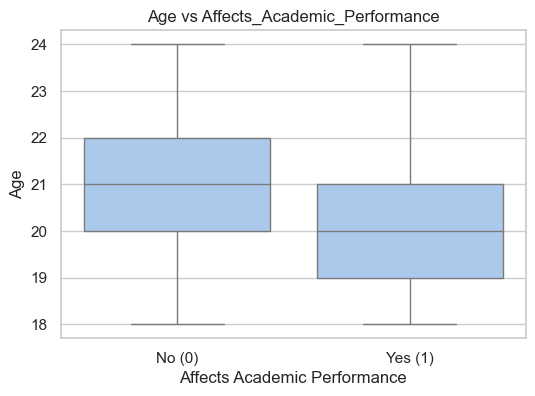

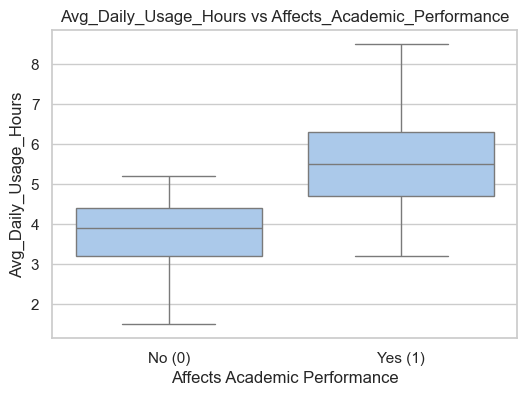

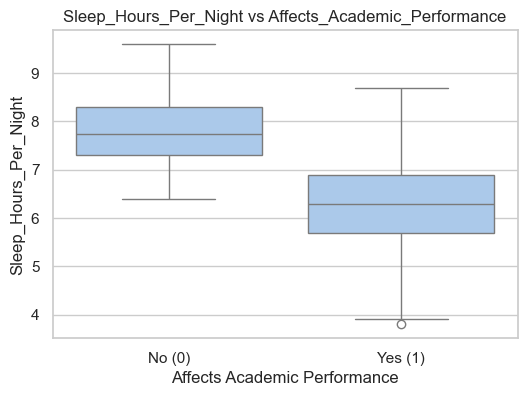

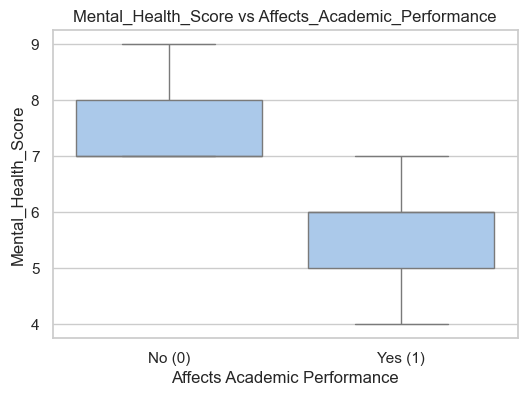

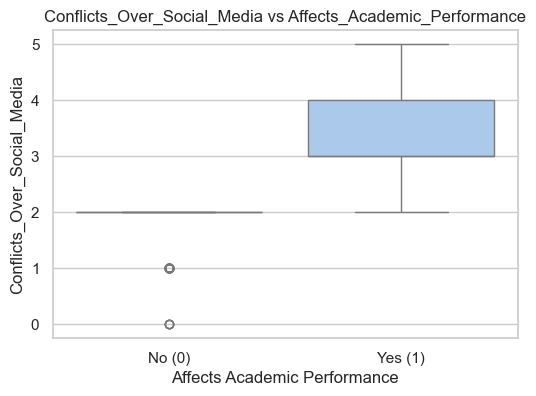

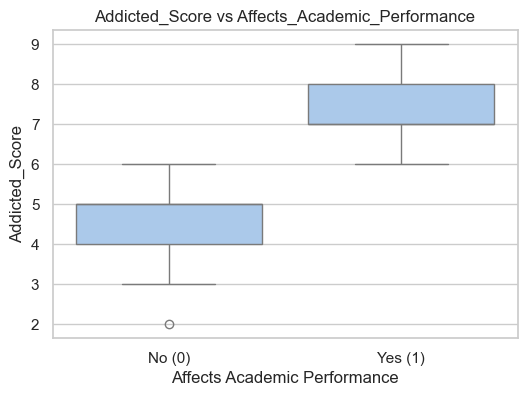

In [43]:
# plot numeric predictors vs academic impact
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        data=df,
        x="Affects_Academic_Performance_binary",
        y=col
    )
    plt.xticks([0, 1], ["No (0)", "Yes (1)"])
    plt.title(f"{col} vs Affects_Academic_Performance")
    plt.xlabel("Affects Academic Performance")
    plt.ylabel(col)
    plt.show()

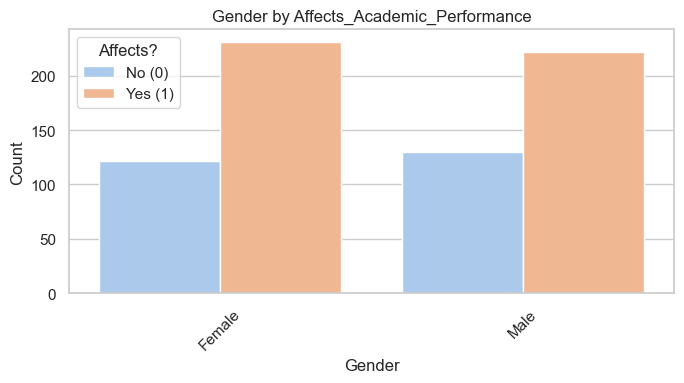

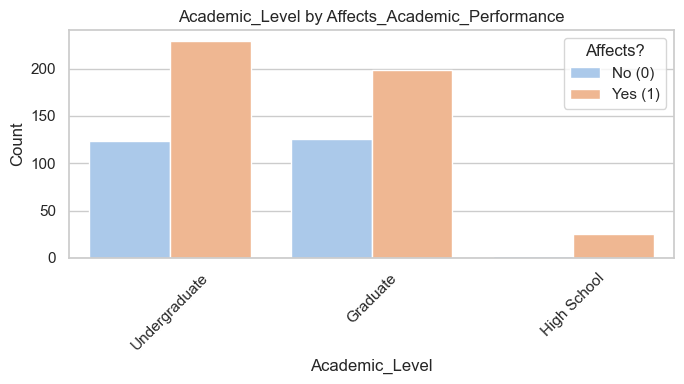

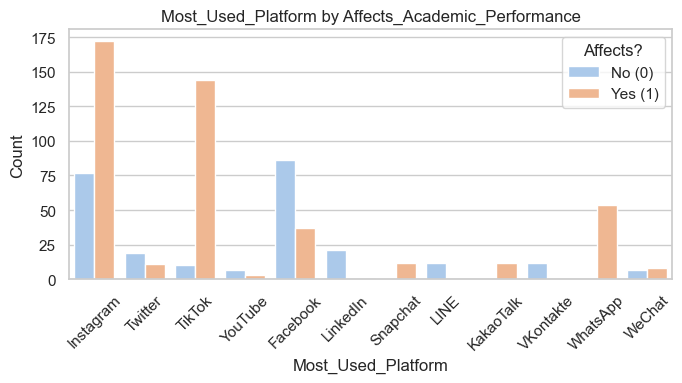

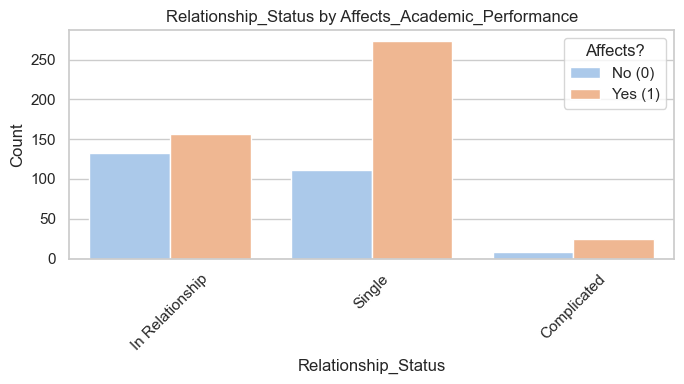

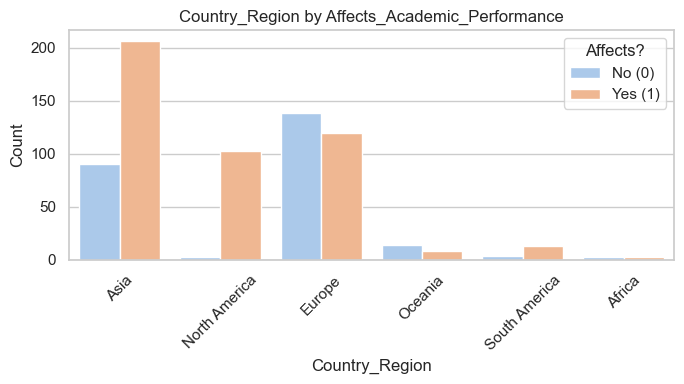

In [45]:
# plot categorical predictors vs academic impact
for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(
        data=df,
        x=col,
        hue="Affects_Academic_Performance_binary"
    )
    plt.title(f"{col} by Affects_Academic_Performance")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Affects?", labels=["No (0)", "Yes (1)"])
    plt.tight_layout()
    plt.show()

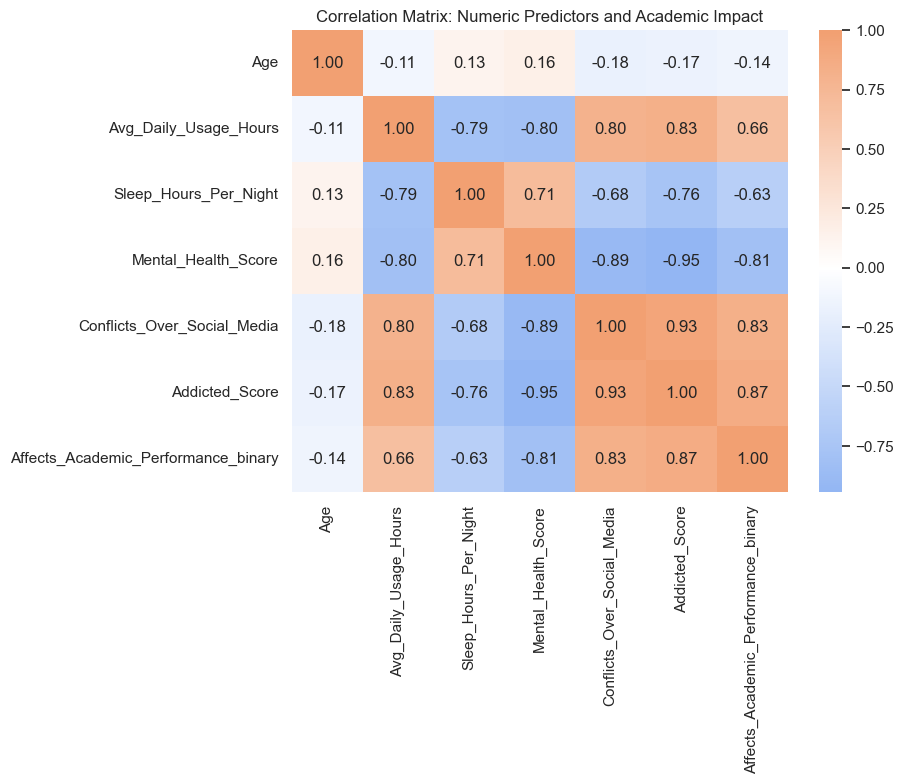

In [59]:
# plot correlation heatmap for numeric predictors & target
corr_cols = numeric_cols + ["Affects_Academic_Performance_binary"]
corr_matrix = df[corr_cols].corr()

custom_cmap = LinearSegmentedColormap.from_list(
    "color_corr",
    ["#8DB2F2", "#FFFFFF", "#F2A072"]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0   
)
plt.title("Correlation Matrix: Numeric Predictors and Academic Impact")
plt.show()

The heatmap shows that higher social media addiction, conflicts over social media, and daily usage hours are positively correlated with reporting academic impact, while sleep and mental health scores are negatively correlated. These relationships support the expectation that heavier or problematic social media use is associated with poorer academic outcomes.

### IV. Modeling
- Logistic Regression
- Decision Tree
- Random Forest
- Stratified 10-fold cross-validation
- Evaluation metrics:

#### Stratified 10-Fold Cross-Validation Setup

We use stratified 10-fold cross-validation to evaluate all models. Stratification preserves the class distribution in each fold, which is important given the slight imbalance in the target variable. Using the same cross-validation splits across all models ensures a fair performance comparison.

In [71]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def evaluate_model(model, X, y):
    accuracy  = cross_val_score(model, X, y, cv=skf, scoring='accuracy').mean()
    precision = cross_val_score(model, X, y, cv=skf, scoring='precision').mean()
    recall    = cross_val_score(model, X, y, cv=skf, scoring='recall').mean()
    f1        = cross_val_score(model, X, y, cv=skf, scoring='f1').mean()
    return accuracy, precision, recall, f1

#### Logistic Regression

In [77]:
# cross-validated performance
log_reg = LogisticRegression(max_iter=1000)
log_results = evaluate_model(log_reg, X_scaled, y)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [log_results[0], log_results[1], log_results[2], log_results[3]]
})

metrics_table

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-Score,1.0


In [78]:
# fitted logistic regression
log_reg_full = LogisticRegression(max_iter=1000)
log_reg_full.fit(X_scaled, y)

LogisticRegression(max_iter=1000)

In [81]:
# coefficient table and odds ratio
coef_table = pd.DataFrame({
    "Feature": X_scaled.columns,
    "Coefficient": log_reg_full.coef_[0],
})

coef_table["Odds_Ratio"] = np.exp(coef_table["Coefficient"])
coef_table_sorted = coef_table.sort_values("Coefficient", ascending=False)

coef_table_sorted.head(10)

,Feature,Coefficient,Odds_Ratio
4,Conflicts_Over_Social_Media,3.785493,44.057387
5,Addicted_Score,2.543748,12.727287
14,Most_Used_Platform_TikTok,0.553903,1.740032
24,Country_Region_North America,0.513690,1.671447
21,Relationship_Status_Single,0.472385,1.603815
10,Most_Used_Platform_KakaoTalk,0.416398,1.516490
1,Avg_Daily_Usage_Hours,0.382035,1.465264
9,Most_Used_Platform_Instagram,0.360130,1.433516
25,Country_Region_Oceania,0.280465,1.323745
18,Most_Used_Platform_WhatsApp,0.061360,1.063281


/var/folders/jy/x5phhml51pq49h8f4l9rzwlc0000gn/T/ipykernel_59830/3714282346.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


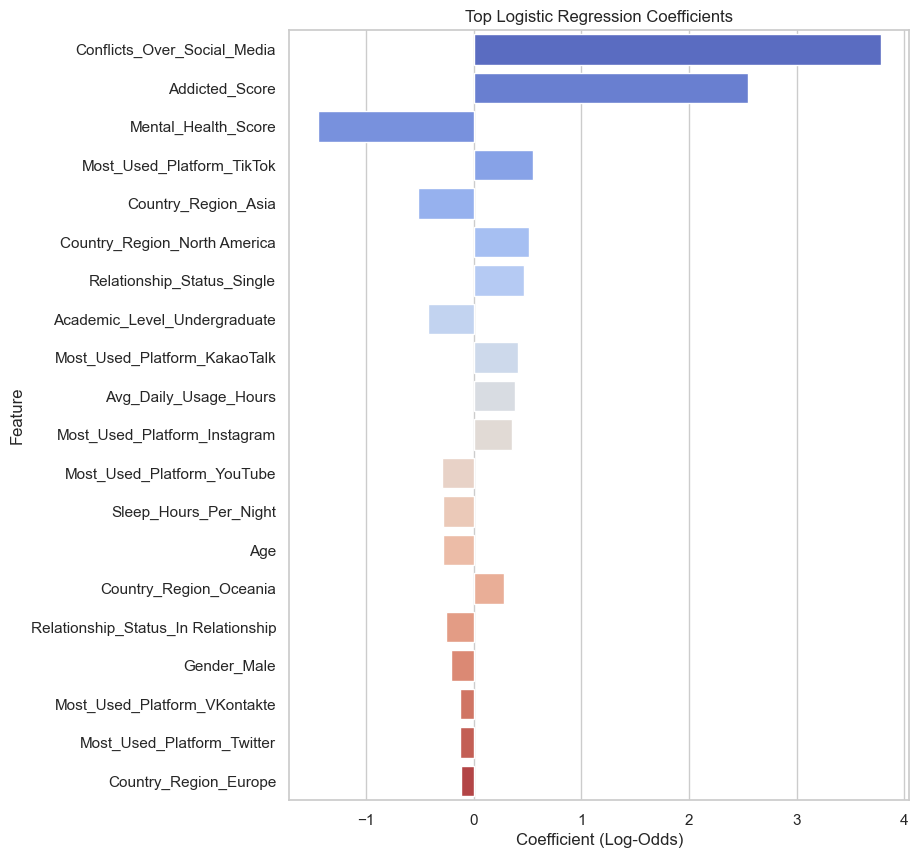

In [82]:
# plot coefficients
top_coef = coef_table.reindex(
    coef_table["Coefficient"].abs().sort_values(ascending=False).index
)

plt.figure(figsize=(8, 10))
sns.barplot(
    data=top_coef.head(20),
    x="Coefficient",
    y="Feature",
    palette="coolwarm"
)
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient (Log-Odds)")
plt.ylabel("Feature")
plt.show()

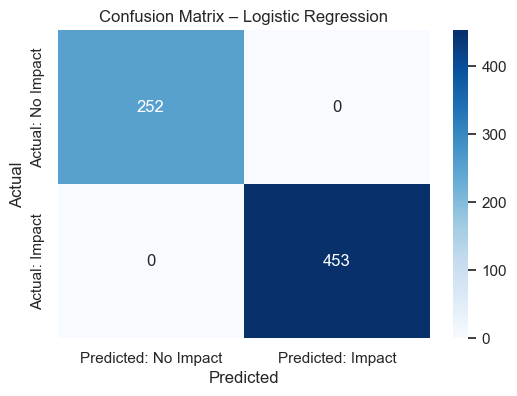

In [103]:
# confusion matrix heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: No Impact", "Predicted: Impact"],
            yticklabels=["Actual: No Impact", "Actual: Impact"])
plt.title("Confusion Matrix – Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Logistic Regression achieves perfect predictive performance (accuracy, precision, recall, and F1 = 1.00). Although perfect scores are very uncommon in behavioral datasets, this result is expected in our case because the dataset is highly separable. As shown in the EDA section, predictors such as `Addicted_Score` and `Conflicts_Over_Social_Media` exhibit extremely strong correlations with the academic impact label (r = 0.87 and r = 0.83, respectively). These relationships create a linear boundary that separates the two classes without overlap, allowing Logistic Regression to classify every observation correctly across all folds of cross-validation.

Coefficient and odds ratio analysis confirm that addiction-related behaviors strongly increase the odds of experiencing academic impact, while greater sleep duration and higher mental health scores reduce those odds. The confusion matrix shows zero misclassifications, which reflects the structured, rule-based nature of the dataset.

#### Decision Tree Classifier

In [89]:
# cross-validated performance
dt = DecisionTreeClassifier(random_state=42)
dt_results = evaluate_model(dt, X_encoded, y)

metrics_dt = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": dt_results
})
metrics_dt

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-Score,1.0


In [91]:
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_encoded, y)

DecisionTreeClassifier(random_state=42)

In [93]:
# feature importance table
dt_importances = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": dt_full.feature_importances_
}).sort_values("Importance", ascending=False)

dt_importances.head(15)


,Feature,Importance
4,Conflicts_Over_Social_Media,0.981691
3,Mental_Health_Score,0.018309
0,Age,0.000000
2,Sleep_Hours_Per_Night,0.000000
1,Avg_Daily_Usage_Hours,0.000000
5,Addicted_Score,0.000000
6,Gender_Male,0.000000
7,Academic_Level_High School,0.000000
8,Academic_Level_Undergraduate,0.000000
9,Most_Used_Platform_Instagram,0.000000


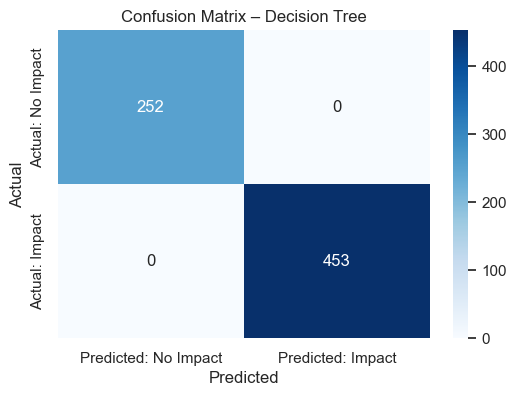

In [102]:
# confusion matrix
y_pred_dt = dt_full.predict(X_encoded)
cm_dt = confusion_matrix(y, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted: No Impact", "Predicted: Impact"],
    yticklabels=["Actual: No Impact", "Actual: Impact"]
)
plt.title("Confusion Matrix – Decision Tree")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


The Decision Tree also achieves perfect scores across all cross-validation metrics. While Decision Trees often overfit, the dataset’s structure makes classification extremely easy. The variable `Conflicts_Over_Social_Media` nearly perfectly separates the two classes on its own. Consequently, the tree uses this feature as the first split and is able to classify all observations with a single rule.

Feature importance results highlight this behavior clearly. More than 98% of the importance is assigned to `Conflicts_Over_Social_Media`, with the remaining features near zero. This does not mean the other variables lack predictive power. Instead, the tree simply never needed to use them because the dominant feature captured the full decision boundary. This is characteristic of highly separable or synthetic survey data where one or two variables implicitly encode the target.

The confusion matrix again shows zero errors. While the Decision Tree performs perfectly in this dataset, its reliance on a single feature suggests potential instability in more complex or noisy real-world data.

#### Random Forest Classifier

In [90]:
# cross-validated performance
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf_results = evaluate_model(rf, X_encoded, y)

metrics_rf = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": rf_results
})
metrics_rf

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-Score,1.0


In [96]:
rf_full = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
rf_full.fit(X_encoded, y)

RandomForestClassifier(n_estimators=300, random_state=42)

In [99]:
# feature importance table
rf_importances = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_full.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importances.head(10)

,Feature,Importance
4,Conflicts_Over_Social_Media,0.321488
5,Addicted_Score,0.269075
3,Mental_Health_Score,0.183312
2,Sleep_Hours_Per_Night,0.090108
1,Avg_Daily_Usage_Hours,0.071076
14,Most_Used_Platform_TikTok,0.013984
24,Country_Region_North America,0.010940
23,Country_Region_Europe,0.007408
0,Age,0.003810
9,Most_Used_Platform_Instagram,0.003652


/var/folders/jy/x5phhml51pq49h8f4l9rzwlc0000gn/T/ipykernel_59830/3893600807.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


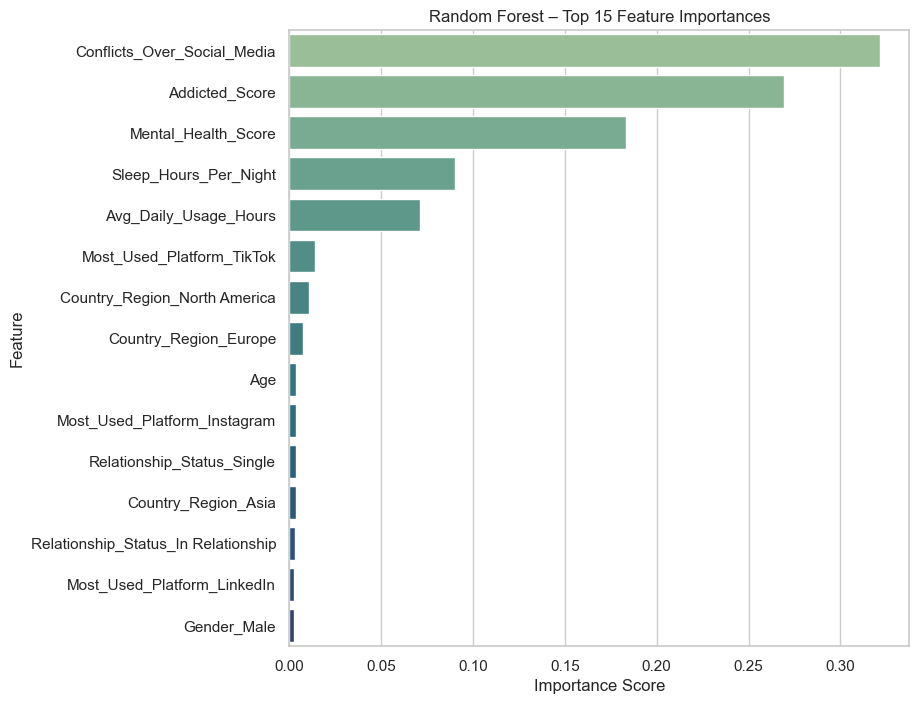

In [100]:
# plot feature importance table
top_rf = rf_importances.head(15)

plt.figure(figsize=(8, 8))
sns.barplot(
    data=top_rf,
    x="Importance",
    y="Feature",
    palette="crest"
)
plt.title("Random Forest – Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

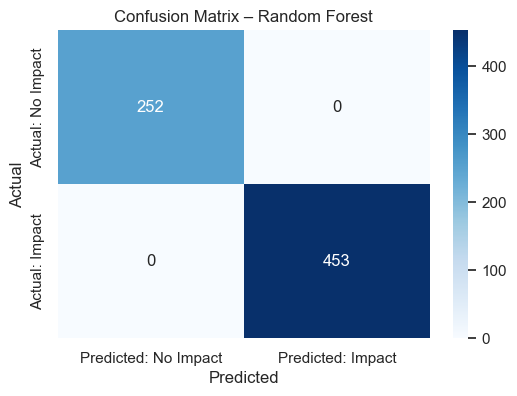

In [101]:
# confusion matrix
y_pred_rf = rf_full.predict(X_encoded)
cm_rf = confusion_matrix(y, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted: No Impact", "Predicted: Impact"],
    yticklabels=["Actual: No Impact", "Actual: Impact"]
)
plt.title("Confusion Matrix – Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

The Random Forest classifier also achieved perfect cross-validated performance, indicating that the dataset is highly separable and contains very strong signals linking social media behavior to academic impact. The feature importances show that the model relies primarily on a small set of behavioral variables, `Conflicts_Over_Social_Media`, `Addicted_Score`, `Mental_Health_Score`, `Sleep_Hours_Per_Night`, and `Avg_Daily_Usage_Hours`, which collectively explain nearly all of the predictive power. Demographic factors and most platform-use variables contribute minimally. The consistency of these results with the logistic regression and decision tree models suggests that the underlying relationships in the dataset are unusually strong and clean, enabling the Random Forest to classify outcomes without error. As with the earlier models, the perfect accuracy should be interpreted cautiously, as real-world behavioral data is typically noisier and less perfectly separable.